In [1]:
# Package imports
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Dataframe
import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic plot
import seaborn as sns                               # Advanced dataviz

## Question 1

The data frame below shows the evolution of the average duration of a first marriage in Belgium, since 2015 by type of marriage (male-female / female-female / male-male) (Source: StatBel). Can we say that a man-man marriage lasts significantly longer than a woman-woman marriage?  
Make a plot!



TtestResult(statistic=np.float64(1.4380467770885657), pvalue=np.float64(0.08498263218922128), df=np.float64(15.773404423131526))


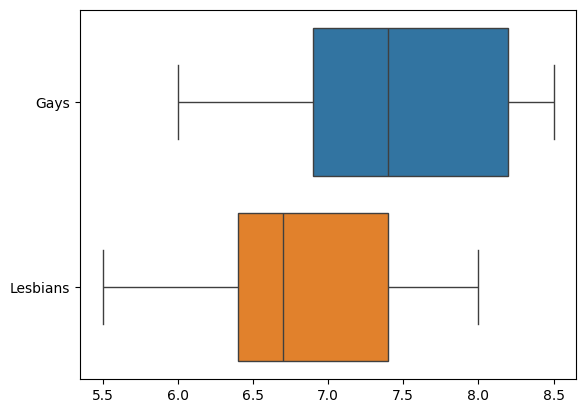

In [ ]:
divorces = pd.DataFrame(data={
    'year': [2015,2016,2017,2018,2019,2020,2021,2022,2023],
    'm_f': [16.7, 16.9, 16.9, 16.7, 16.7, 16.4, 16.6, 16.7, 16.1],
    'f_f': [5.5, 6.4, 6.3, 7.4, 6.7, 6.7, 7.0, 7.8, 8.0],
    'm_m': [6.0, 6.3, 6.9, 7.4, 7.4, 8.0, 8.2, 8.2, 8.5]
}).set_index('year')
divorces.head()

gay = divorces.m_m
lesbian = divorces.f_f

sns.boxplot(
    data=pd.DataFrame({'Gays': gay, 'Lesbians': lesbian}),
    orient='h');

#H0: Gay and lesbian marriages last the same
#H1: Hgay - Hlesbian > 0

print(stats.ttest_ind(a=gay, b=lesbian,
    alternative='greater', equal_var=False))

#pvalue is slightly bigger than 0.05, so we cannot reject the null hypothesis.


## Question 2

The data frame below shows the evolution of the average duration of a first and a subsequent marriage in Belgium since 2015 (Source: StatBel). Can we say that a first marriage lasts significantly longer than a subsequent marriage? Make a plot!


TtestResult(statistic=np.float64(32.73281656361965), pvalue=np.float64(3.07965306749712e-14), df=np.float64(13.080346689617489))


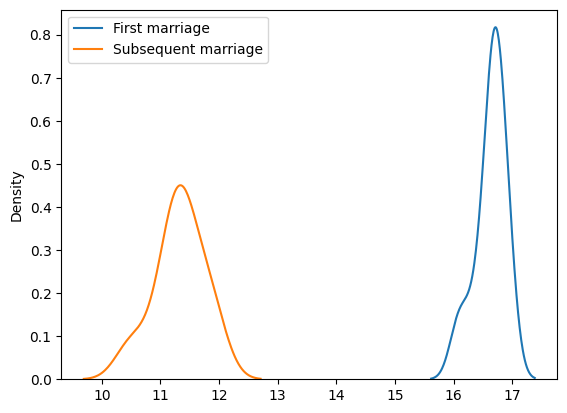

In [ ]:
divorces = pd.DataFrame(data={
    'year': [2015,2016,2017,2018,2019,2020,2021,2022,2023],
    'first_marriage': [16.7, 16.9, 16.9, 16.7, 16.7, 16.4, 16.6, 16.7, 16.1],
    'subsequent_marriage': [10.5, 11.0, 11.2, 11.3, 11.3, 11.4, 11.5, 11.9, 11.8]
}).set_index('year')
divorces.head()

one = divorces.first_marriage
two = divorces.subsequent_marriage

sns.kdeplot(
    data=pd.DataFrame({'First marriage': one, 'Subsequent marriage': two}),
    );

#H0: First and second marriages last the same
#H1: Hfirst - Hsecond > 0

print(stats.ttest_ind(a=one, b=two,
    alternative='greater', equal_var=False))

#pvalue is almost zero, so we can reject the null hypothesis. A first marriage lasts longer than a subsequent marriage.

## Question 3
A local pizzeria claims that they can deliver pizza faster than a local branch of a large chain. To verify this, you ordered pizza from both of them 10 times. Below are the times (in minutes) they took. Can the local pizzeria indeed deliver pizzas significantly faster than the big player? Make a plot.



TtestResult(statistic=np.float64(-1.6341014912018457), pvalue=np.float64(0.059853604215369484), df=np.float64(17.89441184884079))


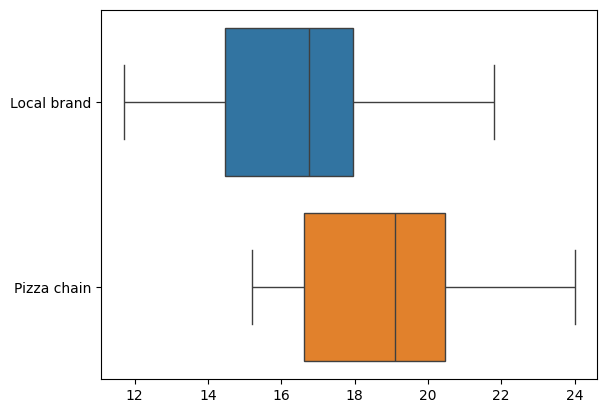

In [ ]:
dfpizzas = pd.DataFrame(data= {'local': [16.8, 11.7, 15.6, 16.7, 17.5, 18.1, 14.1, 21.8, 13.9, 20.8],
                               'chain': [22.0, 15.2, 18.7, 15.6, 20.8, 19.5, 17.0, 19.5, 16.5, 24.0]})
dfpizzas.head()

sns.boxplot(
    data=pd.DataFrame({'Local brand': dfpizzas.local, 'Pizza chain': dfpizzas.chain}),
    orient='h');

#H0: Delivery times are the same
#H1: Hlocal - Hchain < 0

print(stats.ttest_ind(a=dfpizzas.local, b=dfpizzas.chain,
    alternative='less', equal_var=False))

    #Slightly bigger than the alpha 0.05, so we do not reject the null hypothesis, we cannot ensure the local pizzeria delivers faster than the chain.
